# 03 Cancer Cohort Profile and Descriptive Analysis



## Notebook objectives

1. Load the cleaned SPARCS datasets from Notebook 02.
2. Confirm cohort counts and development/final modelling status.
3. Describe the primary cancer admission cohort.
4. Compare primary cancer admissions with non-cancer admissions.
5. Summarise diagnosis mix, demographics, admission type, payer, severity, length of stay, charges and costs.
6. Export cleaner tables and figures for the report and portfolio README.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path
import textwrap

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Detect project directory whether notebook is run from root folder or /notebooks
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_dir = current_dir.parent
else:
    project_dir = current_dir

data_processed = project_dir / "data" / "processed"
outputs_tables = project_dir / "outputs" / "tables"
outputs_figures = project_dir / "outputs" / "figures"

for folder in [data_processed, outputs_tables, outputs_figures]:
    folder.mkdir(parents=True, exist_ok=True)

print("Current directory:", current_dir)
print("Project directory:", project_dir)
print("Processed data folder:", data_processed)
print("Tables output folder:", outputs_tables)
print("Figures output folder:", outputs_figures)


Current directory: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/notebooks
Project directory: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost
Processed data folder: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/data/processed
Tables output folder: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/tables
Figures output folder: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures


## 1. Helper functions for cleaner outputs



In [2]:
def money_formatter(x, pos):
    """Format axis labels as compact USD values."""
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:.0f}"

def comma_formatter(x, pos):
    """Format axis labels with commas."""
    return f"{x:,.0f}"

def clean_label(label, width=34):
    """Convert long all-caps labels into wrapped title-case labels."""
    if pd.isna(label):
        return "Missing"
    label = str(label).replace(" - ", ": ")
    label = label.title()
    return "\n".join(textwrap.wrap(label, width=width))

def add_bar_labels(ax, fmt="{:.0f}", padding=3):
    """Add value labels to vertical bars."""
    labels = []
    for patch in ax.patches:
        height = patch.get_height()
        if pd.isna(height):
            labels.append("")
        else:
            labels.append(fmt.format(height))
    ax.bar_label(ax.containers[0], labels=labels, padding=padding)

def add_horizontal_bar_labels(ax, fmt="{:.0f}", padding=3):
    """Add value labels to horizontal bars."""
    labels = []
    for patch in ax.patches:
        width = patch.get_width()
        if pd.isna(width):
            labels.append("")
        else:
            labels.append(fmt.format(width))
    ax.bar_label(ax.containers[0], labels=labels, padding=padding)

def save_current_figure(filename):
    fig_path = outputs_figures / filename
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)


## 2. Load cleaned datasets from Notebook 02

The main descriptive work uses:

- `sparcs_2024_cleaned_with_flags.csv`: full cleaned dataset with cancer flags
- `sparcs_2024_primary_cancer_cohort_clean.csv`: strict primary cancer cohort
- `sparcs_2024_broader_cancer_related_cohort_clean.csv`: broader cancer-related cohort
- `sparcs_2024_model_input.csv`: strict primary cancer cohort with valid outcome fields


In [3]:
required_files = {
    "full_cleaned": data_processed / "sparcs_2024_cleaned_with_flags.csv",
    "primary_cancer": data_processed / "sparcs_2024_primary_cancer_cohort_clean.csv",
    "broader_cancer": data_processed / "sparcs_2024_broader_cancer_related_cohort_clean.csv",
    "model_input": data_processed / "sparcs_2024_model_input.csv"
}

missing_files = [name for name, path in required_files.items() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing required processed files from Notebook 02: "
        + ", ".join(missing_files)
        + ". Rerun Notebook 02 before continuing."
    )

df_clean = pd.read_csv(required_files["full_cleaned"], low_memory=False)
primary_cancer = pd.read_csv(required_files["primary_cancer"], low_memory=False)
broader_cancer = pd.read_csv(required_files["broader_cancer"], low_memory=False)
model_input = pd.read_csv(required_files["model_input"], low_memory=False)

print("Full cleaned dataset:", df_clean.shape)
print("Primary cancer cohort:", primary_cancer.shape)
print("Broader cancer-related cohort:", broader_cancer.shape)
print("Model input:", model_input.shape)

df_clean.head()


Full cleaned dataset: (50000, 49)
Primary cancer cohort: (1218, 49)
Broader cancer-related cohort: (1377, 49)
Model input: (1218, 49)


,discharge_year,health_service_area,hospital_county,facility_name,permanent_facility_id,zip_code,age_group,gender,race,ethnicity,type_of_admission,patient_disposition,emergency_department_indicator,emergency_department_flag,is_emergency_admission,discharged_home_flag,length_of_stay_raw,length_of_stay_clean,length_of_stay_topcoded,length_of_stay_invalid,ccsr_diagnosis_code,ccsr_diagnosis_code_clean,ccsr_diagnosis_description,cancer_cohort_type,is_primary_cancer_admission,is_broader_cancer_related_admission,is_excluded_cancer_keyword_match,cancer_category,cancer_group,apr_drg_code,apr_drg_description,apr_mdc_code,apr_mdc_description,apr_severity_of_illness_code,apr_severity_of_illness,apr_risk_of_mortality,apr_medical_surgical,ccsr_procedure_code,ccsr_procedure_description,payment_typology_1,primary_payer,payment_typology_2,payment_typology_3,total_charges,total_charges_clean,log_total_charges_clean,total_costs,total_costs_clean,log_total_costs_clean
0,2024,Hudson Valley,Westchester,WESTCHESTER MEDICAL CENTER,1139.0,OOS,0-17,F,White,Not Span/Hispanic,Emergency,Home or Self Care,Y,1,1,1,1,1,False,False,SYM002,SYM002,FEVER,non_cancer,0,0,0,Non-cancer or excluded category,non_cancer,722,FEVER AND INFLAMMATORY CONDITIONS,18,"INFECTIOUS AND PARASITIC DISEASES, SYSTEMIC OR...",2,Moderate,Minor,Medical,Unknown,Unknown,Private Health Insurance,Private Health Insurance,Unknown,Unknown,46814.00,46814.00,10.753938,6772.07,6772.07,8.820562
1,2024,New York City,Queens,FLUSHING HOSPITAL MEDICAL CENTER,1628.0,113,0-17,M,White,Spanish/Hispanic,Emergency,Home or Self Care,Y,1,1,1,2,2,False,False,SYM002,SYM002,FEVER,non_cancer,0,0,0,Non-cancer or excluded category,non_cancer,722,FEVER AND INFLAMMATORY CONDITIONS,18,"INFECTIOUS AND PARASITIC DISEASES, SYSTEMIC OR...",2,Moderate,Moderate,Medical,Unknown,Unknown,Medicaid,Medicaid,Unknown,Unknown,13490.00,13490.00,9.509704,15464.30,15464.30,9.646289
2,2024,New York City,New York,NEW YORK-PRESBYTERIAN HOSPITAL - NEW YORK WEIL...,1458.0,100,70 or Older,M,White,Not Span/Hispanic,Emergency,Home or Self Care,Y,1,1,1,2,2,False,False,SYM002,SYM002,FEVER,non_cancer,0,0,0,Non-cancer or excluded category,non_cancer,722,FEVER AND INFLAMMATORY CONDITIONS,18,"INFECTIOUS AND PARASITIC DISEASES, SYSTEMIC OR...",2,Moderate,Moderate,Medical,ADM012,CHEMOTHERAPY,Medicare,Medicare,Private Health Insurance,Unknown,49503.16,49503.16,10.809792,9324.77,9324.77,9.140430
3,2024,New York City,New York,NEW YORK-PRESBYTERIAN HOSPITAL - COLUMBIA PRES...,1464.0,100,0-17,F,Other Race,Not Span/Hispanic,Emergency,Home or Self Care,Y,1,1,1,1,1,False,False,SYM002,SYM002,FEVER,non_cancer,0,0,0,Non-cancer or excluded category,non_cancer,722,FEVER AND INFLAMMATORY CONDITIONS,18,"INFECTIOUS AND PARASITIC DISEASES, SYSTEMIC OR...",1,Minor,Minor,Medical,CNS002,LUMBAR PUNCTURE,Private Health Insurance,Private Health Insurance,Unknown,Unknown,27827.66,27827.66,10.233786,7304.27,7304.27,8.896214
4,2024,New York City,New York,MOUNT SINAI WEST,1466.0,100,18-29,F,Other Race,Spanish/Hispanic,Emergency,Home or Self Care,Y,1,1,1,1,1,False,False,SYM002,SYM002,FEVER,non_cancer,0,0,0,Non-cancer or excluded category,non_cancer,722,FEVER AND INFLAMMATORY CONDITIONS,18,"INFECTIOUS AND PARASITIC DISEASES, SYSTEMIC OR...",2,Moderate,Minor,Medical,ADM021,"ADMINISTRATION OF THERAPEUTIC SUBSTANCES, NEC",Medicare,Medicare,Unknown,Unknown,32798.29,32798.29,10.398132,7948.10,7948.10,8.980688


## 3. Confirm required variables and create fallback fields



In [4]:
# Create fallback variables if needed

for dataset in [df_clean, primary_cancer, broader_cancer, model_input]:
    if "primary_payer" not in dataset.columns and "payment_typology_1" in dataset.columns:
        dataset["primary_payer"] = dataset["payment_typology_1"]

    if "emergency_department_flag" not in dataset.columns and "emergency_department_indicator" in dataset.columns:
        dataset["emergency_department_flag"] = (
            dataset["emergency_department_indicator"]
            .astype("string")
            .str.strip()
            .str.lower()
            .isin(["y", "yes", "true", "1"])
        )

    if "is_emergency_admission" not in dataset.columns and "type_of_admission" in dataset.columns:
        dataset["is_emergency_admission"] = (
            dataset["type_of_admission"]
            .astype("string")
            .str.strip()
            .str.lower()
            .eq("emergency")
        )

    if "ccsr_diagnosis_code_clean" not in dataset.columns and "ccsr_diagnosis_code" in dataset.columns:
        dataset["ccsr_diagnosis_code_clean"] = (
            dataset["ccsr_diagnosis_code"]
            .astype("string")
            .str.strip()
            .str.upper()
        )

required_descriptive_columns = [
    "cancer_cohort_type",
    "ccsr_diagnosis_code_clean",
    "ccsr_diagnosis_description",
    "age_group",
    "gender",
    "race",
    "ethnicity",
    "type_of_admission",
    "patient_disposition",
    "primary_payer",
    "apr_severity_of_illness",
    "apr_risk_of_mortality",
    "apr_medical_surgical",
    "length_of_stay_clean",
    "total_charges_clean",
    "total_costs_clean"
]

missing_required = [col for col in required_descriptive_columns if col not in df_clean.columns]

if missing_required:
    raise ValueError(f"Missing required descriptive columns: {missing_required}")

print("All required descriptive columns are available.")


All required descriptive columns are available.


## 4. Dataset status and cohort size




In [5]:
validation_path = outputs_tables / "notebook_02_validation_summary.csv"
cohort_size_path = outputs_tables / "notebook_02_cohort_size_assessment.csv"

if validation_path.exists():
    validation_summary = pd.read_csv(validation_path)
    display(validation_summary)
else:
    validation_summary = pd.DataFrame()
    print("Notebook 02 validation summary not found. Continuing with direct dataset checks.")

if cohort_size_path.exists():
    cohort_size_assessment = pd.read_csv(cohort_size_path)
    display(cohort_size_assessment)
else:
    minimum_primary_cancer_rows_for_final_modelling = 500
    cohort_size_assessment = pd.DataFrame({
        "assessment_item": [
            "total_cleaned_rows",
            "primary_cancer_rows",
            "model_input_rows",
            "minimum_primary_cancer_rows_for_final_modelling",
            "suitable_for_final_modelling",
            "analysis_dataset_status"
        ],
        "value": [
            len(df_clean),
            len(primary_cancer),
            len(model_input),
            minimum_primary_cancer_rows_for_final_modelling,
            "Yes" if len(model_input) >= minimum_primary_cancer_rows_for_final_modelling else "No",
            "final_analysis_ready" if len(model_input) >= minimum_primary_cancer_rows_for_final_modelling else "development_sample"
        ]
    })
    display(cohort_size_assessment)

cohort_size_assessment.to_csv(
    outputs_tables / "notebook_03_dataset_status_check.csv",
    index=False
)

try:
    dataset_status = cohort_size_assessment.loc[
        cohort_size_assessment["assessment_item"].eq("analysis_dataset_status"),
        "value"
    ].iloc[0]
except Exception:
    dataset_status = "development_sample" if len(model_input) < 500 else "final_analysis_ready"

status_label = "development sample" if dataset_status == "development_sample" else "analysis dataset"
print("Dataset status label for figures:", status_label)


,metric,value
0,raw_file_name,sparcs_2024_extract_50000.csv
1,raw_file_path,/Users/marissa/Desktop/portfolio/oncology-heal...
2,raw_rows,50000
3,raw_columns,33
4,cleaned_analysis_rows,50000
5,cleaned_analysis_columns,49
6,primary_cancer_rows,1218
7,broader_cancer_related_rows,1377
8,excluded_keyword_match_not_cancer_rows,364
9,model_input_rows_primary_cancer,1218


,assessment_item,value
0,total_cleaned_rows,50000
1,primary_cancer_rows,1218
2,broader_cancer_related_rows,1377
3,model_input_rows,1218
4,minimum_primary_cancer_rows_for_final_modelling,500
5,suitable_for_pipeline_testing,Yes
6,suitable_for_final_modelling,Yes
7,analysis_dataset_status,final_analysis_ready
8,recommended_next_step,Proceed to final descriptive analysis and mode...


Dataset status label for figures: analysis dataset


## 5. Cohort breakdown

This table summarises the full cleaned dataset by cancer cohort type.


In [6]:
cohort_breakdown = (
    df_clean
    .groupby("cancer_cohort_type", dropna=False)
    .agg(
        admissions=("cancer_cohort_type", "size"),
        median_los=("length_of_stay_clean", "median"),
        mean_los=("length_of_stay_clean", "mean"),
        median_total_charges=("total_charges_clean", "median"),
        median_total_costs=("total_costs_clean", "median"),
        emergency_department_percent=("emergency_department_flag", lambda x: x.mean() * 100 if x.notna().any() else np.nan),
        emergency_admission_percent=("is_emergency_admission", lambda x: x.mean() * 100 if x.notna().any() else np.nan)
    )
    .reset_index()
)

cohort_breakdown["percent_of_all_admissions"] = (
    cohort_breakdown["admissions"] / len(df_clean) * 100
)

cohort_breakdown = cohort_breakdown[
    [
        "cancer_cohort_type",
        "admissions",
        "percent_of_all_admissions",
        "median_los",
        "mean_los",
        "median_total_charges",
        "median_total_costs",
        "emergency_department_percent",
        "emergency_admission_percent"
    ]
]

cohort_breakdown.to_csv(
    outputs_tables / "notebook_03_cohort_breakdown.csv",
    index=False
)

display(cohort_breakdown)


,cancer_cohort_type,admissions,percent_of_all_admissions,median_los,mean_los,median_total_charges,median_total_costs,emergency_department_percent,emergency_admission_percent
0,broader_cancer_related_only,159,0.318,4.0,7.194969,77409.000,21382.580,71.069182,74.213836
1,excluded_keyword_match_not_cancer,364,0.728,2.0,3.651099,65101.230,19814.875,20.879121,23.901099
2,non_cancer,48259,96.518,3.0,5.706335,46535.450,13884.610,62.792432,66.679790
3,primary_cancer,1218,2.436,4.0,7.388342,91354.615,27048.660,37.848933,40.311987


## 6. Diagnosis mix in the primary cancer cohort

This table identifies the main cancer diagnosis groups in the strict primary cancer cohort.


In [7]:
primary_diagnosis_mix = (
    primary_cancer
    .groupby(["ccsr_diagnosis_code_clean", "ccsr_diagnosis_description"], dropna=False)
    .agg(
        admissions=("ccsr_diagnosis_code_clean", "size"),
        median_los=("length_of_stay_clean", "median"),
        median_total_charges=("total_charges_clean", "median"),
        median_total_costs=("total_costs_clean", "median")
    )
    .reset_index()
    .sort_values("admissions", ascending=False)
)

primary_diagnosis_mix["percent_of_primary_cancer"] = (
    primary_diagnosis_mix["admissions"] / len(primary_cancer) * 100
)

primary_diagnosis_mix.to_csv(
    outputs_tables / "notebook_03_primary_cancer_diagnosis_mix.csv",
    index=False
)

display(primary_diagnosis_mix.head(30))


,ccsr_diagnosis_code_clean,ccsr_diagnosis_description,admissions,median_los,median_total_charges,median_total_costs,percent_of_primary_cancer
4,NEO022,RESPIRATORY CANCERS,210,3.0,91921.870,28198.200,17.241379
1,NEO015,GASTROINTESTINAL CANCERS - COLORECTAL,202,5.0,91233.670,28558.935,16.584565
14,NEO045,URINARY SYSTEM CANCERS - KIDNEY,82,2.0,72494.220,21839.865,6.732348
17,NEO051,ENDOCRINE SYSTEM CANCERS - PANCREAS,76,6.0,100812.225,28709.120,6.239737
10,NEO039,MALE REPRODUCTIVE SYSTEM CANCERS - PROSTATE,74,1.0,69493.075,20316.985,6.075534
19,NEO058,NON-HODGKIN LYMPHOMA,68,7.0,105730.315,33018.070,5.582923
6,NEO030,BREAST CANCER - ALL OTHER TYPES,66,2.0,83450.650,21911.040,5.418719
15,NEO048,NERVOUS SYSTEM CANCERS - BRAIN,59,4.0,112780.170,39378.960,4.844007
12,NEO043,URINARY SYSTEM CANCERS - BLADDER,48,4.0,92554.425,27100.250,3.940887
23,NEO065,MULTIPLE MYELOMA,43,11.0,185482.310,55322.700,3.530378


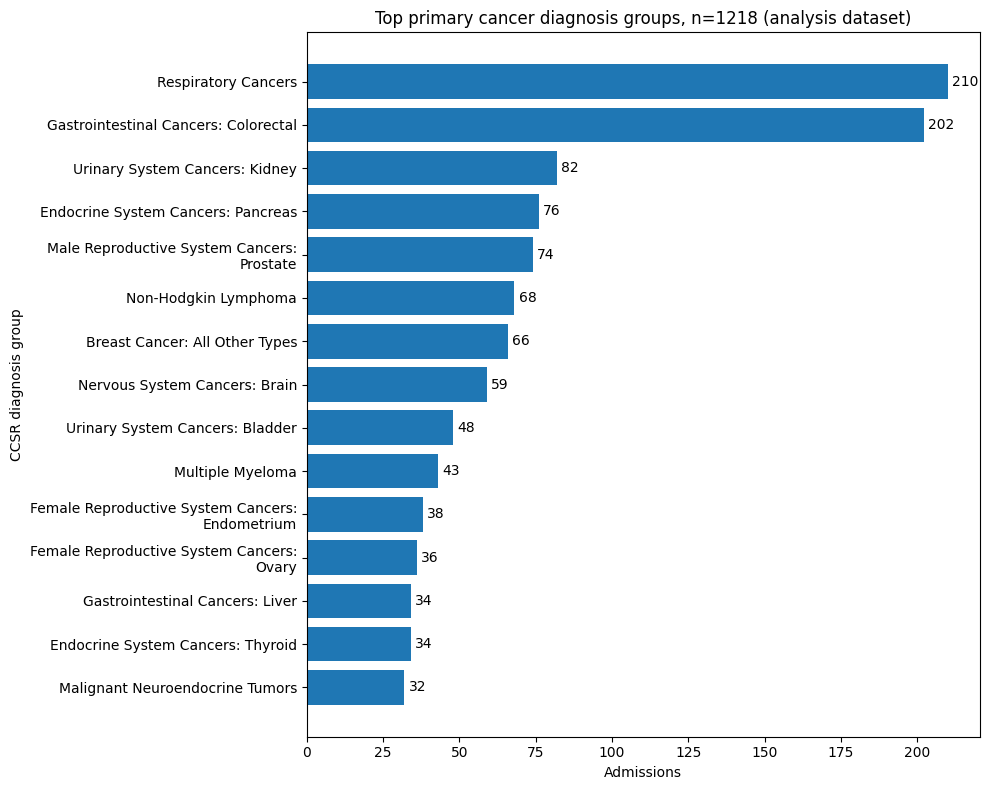

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_03_top_primary_cancer_diagnosis_groups.png


In [8]:
# Figure: top diagnosis groups in primary cancer cohort
# Improvement: wrapped labels and count labels at the end of bars.

top_n = min(15, len(primary_diagnosis_mix))
top_diagnoses = primary_diagnosis_mix.head(top_n).copy()

top_diagnoses["diagnosis_label_clean"] = top_diagnoses["ccsr_diagnosis_description"].apply(
    lambda x: clean_label(x, width=38)
)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    top_diagnoses["diagnosis_label_clean"][::-1],
    top_diagnoses["admissions"][::-1]
)

ax.set_xlabel("Admissions")
ax.set_ylabel("CCSR diagnosis group")
ax.set_title(f"Top primary cancer diagnosis groups, n={len(primary_cancer)} ({status_label})")
add_horizontal_bar_labels(ax, fmt="{:.0f}", padding=3)

plt.tight_layout()
save_current_figure("notebook_03_top_primary_cancer_diagnosis_groups.png")


## 7. Demographic profile of primary cancer admissions

The following tables summarise the primary cancer cohort by age group, gender, race and ethnicity.

Age groups are ordered logically rather than by frequency.


In [9]:
def categorical_profile_table(data, column, denominator=None, category_order=None):
    if denominator is None:
        denominator = len(data)

    table = (
        data[column]
        .fillna("Missing")
        .value_counts(dropna=False)
        .reset_index()
    )
    table.columns = [column, "admissions"]
    table["percent"] = table["admissions"] / denominator * 100

    if category_order is not None:
        order_map = {category: i for i, category in enumerate(category_order)}
        table["_order"] = table[column].map(order_map).fillna(len(order_map))
        table = table.sort_values(["_order", column]).drop(columns=["_order"])

    return table

profile_columns = ["age_group", "gender", "race", "ethnicity"]

demographic_profile_tables = {}

for col in profile_columns:
    table = categorical_profile_table(primary_cancer, col)
    demographic_profile_tables[col] = table
    table.to_csv(outputs_tables / f"notebook_03_primary_cancer_profile_by_{col}.csv", index=False)
    print(f"\nProfile by {col}:")
    display(table)



Profile by age_group:


,age_group,admissions,percent
0,50-69,549,45.073892
1,70 or Older,484,39.737274
2,30-49,145,11.904762
3,0-17,21,1.724138
4,18-29,19,1.559934



Profile by gender:


,gender,admissions,percent
0,M,628,51.559934
1,F,590,48.440066



Profile by race:


,race,admissions,percent
0,White,688,56.486043
1,Other Race,305,25.041051
2,Black/African American,205,16.830870
3,Multi-racial,20,1.642036



Profile by ethnicity:


,ethnicity,admissions,percent
0,Not Span/Hispanic,910,74.712644
1,Spanish/Hispanic,166,13.628900
2,Unknown,139,11.412151
3,Multi-ethnic,3,0.246305


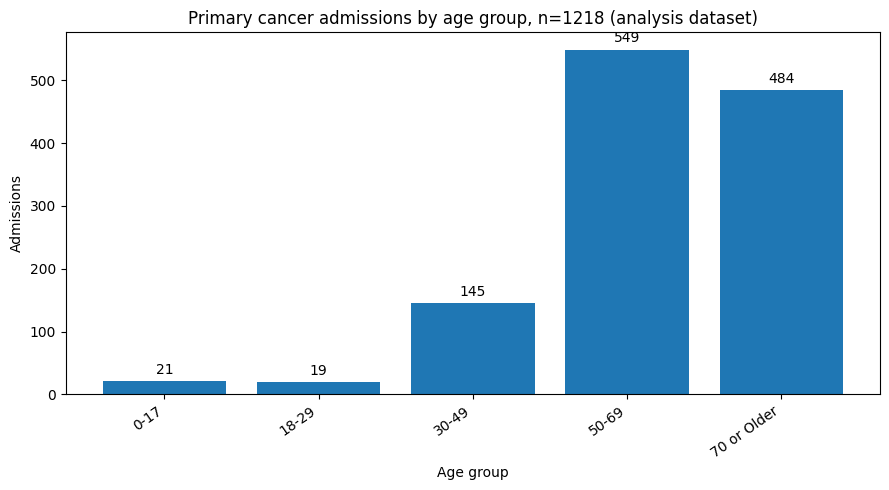

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_03_primary_cancer_age_group_distribution.png


In [10]:
# Figure: age group distribution in primary cancer cohort
# Improvement: logical age ordering and bar labels.

age_order = ["0-17", "18-29", "30-49", "50-69", "70 or Older"]

age_table = categorical_profile_table(
    primary_cancer,
    "age_group",
    category_order=age_order
)

# Keep only groups that appear in the data, but preserve logical order
age_table = age_table[age_table["admissions"] > 0].copy()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(age_table["age_group"], age_table["admissions"])

ax.set_xlabel("Age group")
ax.set_ylabel("Admissions")
ax.set_title(f"Primary cancer admissions by age group, n={len(primary_cancer)} ({status_label})")
add_bar_labels(ax, fmt="{:.0f}", padding=3)

plt.xticks(rotation=35, ha="right")
plt.tight_layout()
save_current_figure("notebook_03_primary_cancer_age_group_distribution.png")


## 8. Admission, payer and severity profile

These variables help describe service use and case-mix differences in the cancer cohort.

Severity is ordered clinically rather than by frequency.


In [11]:
service_profile_columns = [
    "type_of_admission",
    "patient_disposition",
    "primary_payer",
    "apr_severity_of_illness",
    "apr_risk_of_mortality",
    "apr_medical_surgical"
]

service_profile_tables = {}

for col in service_profile_columns:
    table = categorical_profile_table(primary_cancer, col)
    service_profile_tables[col] = table
    table.to_csv(outputs_tables / f"notebook_03_primary_cancer_profile_by_{col}.csv", index=False)
    print(f"\nProfile by {col}:")
    display(table)



Profile by type_of_admission:


,type_of_admission,admissions,percent
0,Elective,615,50.492611
1,Emergency,491,40.311987
2,Urgent,110,9.031199
3,Not Available,2,0.164204



Profile by patient_disposition:


,patient_disposition,admissions,percent
0,Home or Self Care,798,65.517241
1,Home w/ Home Health Services,213,17.487685
2,Skilled Nursing Home,68,5.582923
3,Expired,63,5.172414
4,Hospice - Home,19,1.559934
5,Inpatient Rehabilitation Facility,17,1.395731
6,Hospice - Medical Facility,13,1.067323
7,Short-term Hospital,13,1.067323
8,Left Against Medical Advice,11,0.903120
9,Cancer Center or Childrens Hospital,1,0.082102



Profile by primary_payer:


...

,apr_severity_of_illness,admissions,percent
0,Moderate,464,38.095238
1,Major,405,33.251232
2,Minor,233,19.129721
3,Extreme,116,9.523810



Profile by apr_risk_of_mortality:


,apr_risk_of_mortality,admissions,percent
0,Minor,441,36.206897
1,Moderate,356,29.228243
2,Major,340,27.914614
3,Extreme,81,6.650246



Profile by apr_medical_surgical:


,apr_medical_surgical,admissions,percent
0,Surgical,721,59.195402
1,Medical,497,40.804598


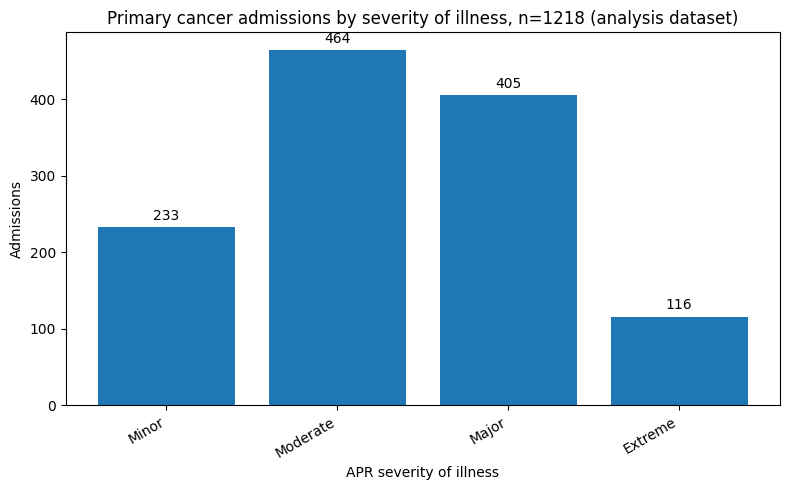

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_03_primary_cancer_severity_distribution.png


In [12]:
# Figure: severity distribution in primary cancer cohort
# Improvement: clinical severity ordering and bar labels.

severity_order = ["Minor", "Moderate", "Major", "Extreme"]

severity_table = categorical_profile_table(
    primary_cancer,
    "apr_severity_of_illness",
    category_order=severity_order
)

severity_table = severity_table[severity_table["admissions"] > 0].copy()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(severity_table["apr_severity_of_illness"], severity_table["admissions"])

ax.set_xlabel("APR severity of illness")
ax.set_ylabel("Admissions")
ax.set_title(f"Primary cancer admissions by severity of illness, n={len(primary_cancer)} ({status_label})")
add_bar_labels(ax, fmt="{:.0f}", padding=3)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_current_figure("notebook_03_primary_cancer_severity_distribution.png")


## 9. Utilisation and cost summary for primary cancer admissions



In [13]:
outcome_columns = ["length_of_stay_clean", "total_charges_clean", "total_costs_clean"]

primary_outcome_summary = (
    primary_cancer[outcome_columns]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
    .T
    .reset_index()
    .rename(columns={"index": "outcome"})
)

primary_outcome_summary.to_csv(
    outputs_tables / "notebook_03_primary_cancer_outcome_summary.csv",
    index=False
)

display(primary_outcome_summary)


,outcome,count,mean,std,min,25%,50%,75%,90%,95%,max
0,length_of_stay_clean,1218.0,7.388342,10.913468,1.00,2.0000,4.000,8.0000,16.000,26.0000,120.00
1,total_charges_clean,1218.0,145211.985608,172271.384448,2077.87,55508.1225,91354.615,164383.6975,305303.122,445185.5235,1838490.55
2,total_costs_clean,1218.0,41849.427611,53370.514032,1146.02,16000.0825,27048.660,47064.5625,84212.608,129372.6735,1004832.53


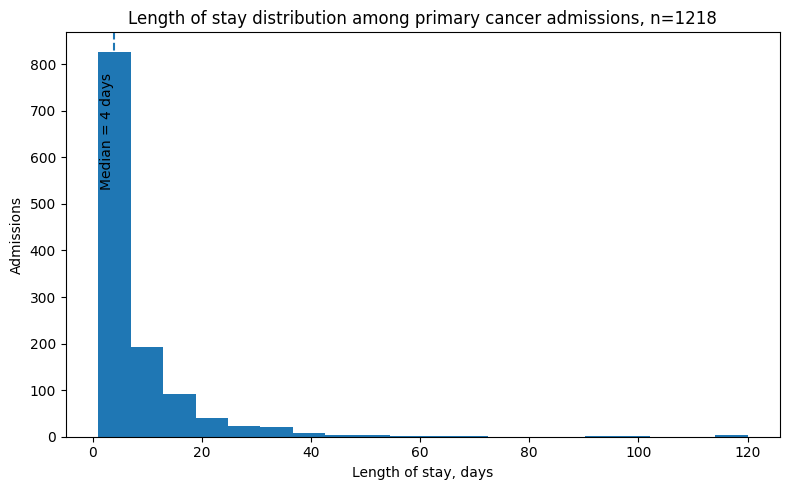

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_03_primary_cancer_los_distribution.png


In [14]:
# Figure: length of stay distribution
# Improvement: median reference line.

median_los = primary_cancer["length_of_stay_clean"].median()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(primary_cancer["length_of_stay_clean"].dropna(), bins=20)
ax.axvline(median_los, linestyle="--", linewidth=1.5)

ax.set_xlabel("Length of stay, days")
ax.set_ylabel("Admissions")
ax.set_title(f"Length of stay distribution among primary cancer admissions, n={len(primary_cancer)}")
ax.text(
    median_los,
    ax.get_ylim()[1] * 0.9,
    f"Median = {median_los:.0f} days",
    rotation=90,
    va="top",
    ha="right"
)

plt.tight_layout()
save_current_figure("notebook_03_primary_cancer_los_distribution.png")


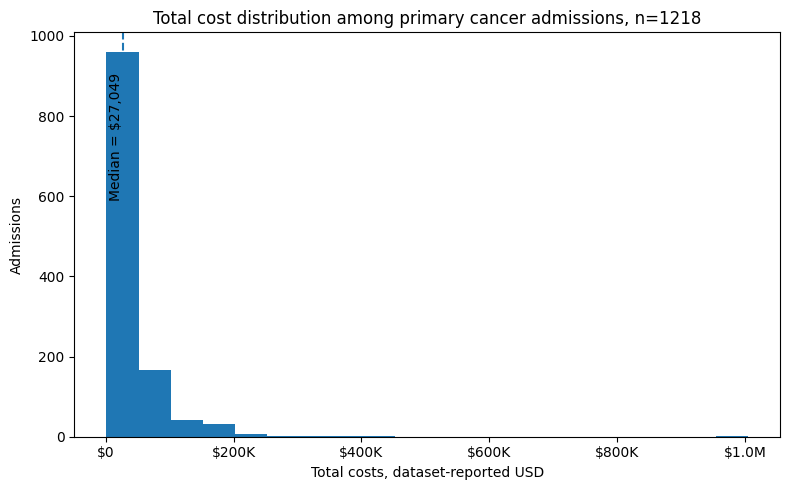

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_03_primary_cancer_total_costs_distribution.png


In [15]:
# Figure: total costs distribution
# Improvement: currency formatting and median reference line.

median_cost = primary_cancer["total_costs_clean"].median()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(primary_cancer["total_costs_clean"].dropna(), bins=20)
ax.axvline(median_cost, linestyle="--", linewidth=1.5)

ax.set_xlabel("Total costs, dataset-reported USD")
ax.set_ylabel("Admissions")
ax.set_title(f"Total cost distribution among primary cancer admissions, n={len(primary_cancer)}")
ax.xaxis.set_major_formatter(FuncFormatter(money_formatter))
ax.text(
    median_cost,
    ax.get_ylim()[1] * 0.9,
    f"Median = ${median_cost:,.0f}",
    rotation=90,
    va="top",
    ha="right"
)

plt.tight_layout()
save_current_figure("notebook_03_primary_cancer_total_costs_distribution.png")


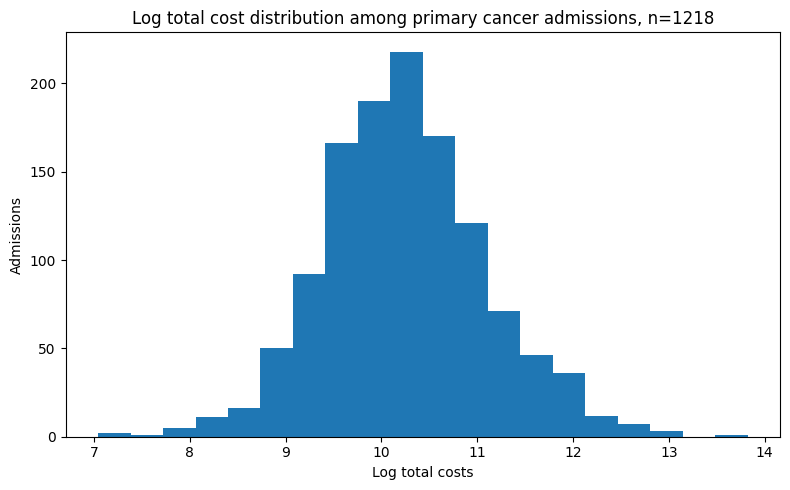

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_03_primary_cancer_log_total_costs_distribution.png


In [16]:
# Figure: log total costs distribution
# Improvement: better view of right-skewed cost data.

positive_costs = primary_cancer.loc[
    primary_cancer["total_costs_clean"] > 0,
    "total_costs_clean"
].copy()

log_costs = np.log(positive_costs)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(log_costs, bins=20)

ax.set_xlabel("Log total costs")
ax.set_ylabel("Admissions")
ax.set_title(f"Log total cost distribution among primary cancer admissions, n={len(positive_costs)}")

plt.tight_layout()
save_current_figure("notebook_03_primary_cancer_log_total_costs_distribution.png")


## 10. Primary cancer versus non-cancer comparison




In [17]:
comparison_data = df_clean[
    df_clean["cancer_cohort_type"].isin(["primary_cancer", "non_cancer"])
].copy()

comparison_data["comparison_group"] = np.where(
    comparison_data["cancer_cohort_type"] == "primary_cancer",
    "Primary cancer",
    "Non-cancer"
)

primary_vs_non_cancer_summary = (
    comparison_data
    .groupby("comparison_group")
    .agg(
        admissions=("comparison_group", "size"),
        median_los=("length_of_stay_clean", "median"),
        mean_los=("length_of_stay_clean", "mean"),
        median_total_charges=("total_charges_clean", "median"),
        median_total_costs=("total_costs_clean", "median"),
        emergency_department_percent=("emergency_department_flag", lambda x: x.mean() * 100 if x.notna().any() else np.nan),
        emergency_admission_percent=("is_emergency_admission", lambda x: x.mean() * 100 if x.notna().any() else np.nan)
    )
    .reset_index()
)

primary_vs_non_cancer_summary.to_csv(
    outputs_tables / "notebook_03_primary_vs_non_cancer_summary.csv",
    index=False
)

display(primary_vs_non_cancer_summary)


,comparison_group,admissions,median_los,mean_los,median_total_charges,median_total_costs,emergency_department_percent,emergency_admission_percent
0,Non-cancer,48259,3.0,5.706335,46535.450,13884.61,62.792432,66.679790
1,Primary cancer,1218,4.0,7.388342,91354.615,27048.66,37.848933,40.311987


In [18]:
# Prepare labels with n for bar charts

plot_table = primary_vs_non_cancer_summary.copy()
plot_table["group_label"] = (
    plot_table["comparison_group"]
    + "\n(n="
    + plot_table["admissions"].astype(int).astype(str)
    + ")"
)

# Ensure non-cancer appears before primary cancer
comparison_order = ["Non-cancer", "Primary cancer"]
plot_table["_order"] = plot_table["comparison_group"].map({v: i for i, v in enumerate(comparison_order)})
plot_table = plot_table.sort_values("_order").drop(columns="_order")


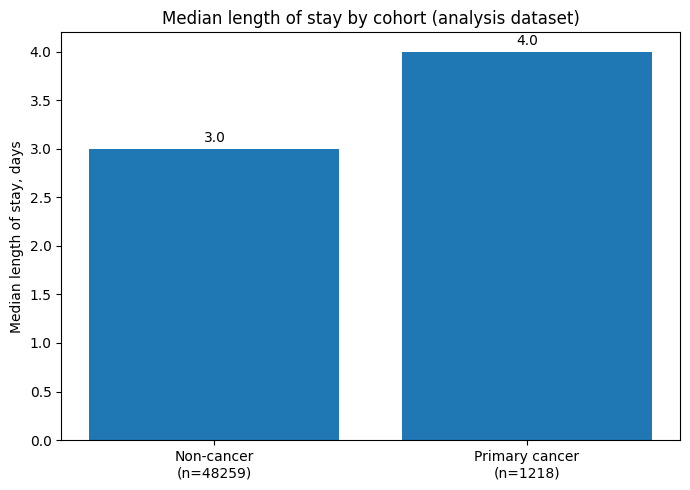

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_03_median_los_primary_vs_non_cancer.png


In [19]:
# Figure: median LOS by comparison group
# Improvement: n labels and value labels.

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(plot_table["group_label"], plot_table["median_los"])

ax.set_ylabel("Median length of stay, days")
ax.set_title(f"Median length of stay by cohort ({status_label})")
add_bar_labels(ax, fmt="{:.1f}", padding=3)

plt.tight_layout()
save_current_figure("notebook_03_median_los_primary_vs_non_cancer.png")


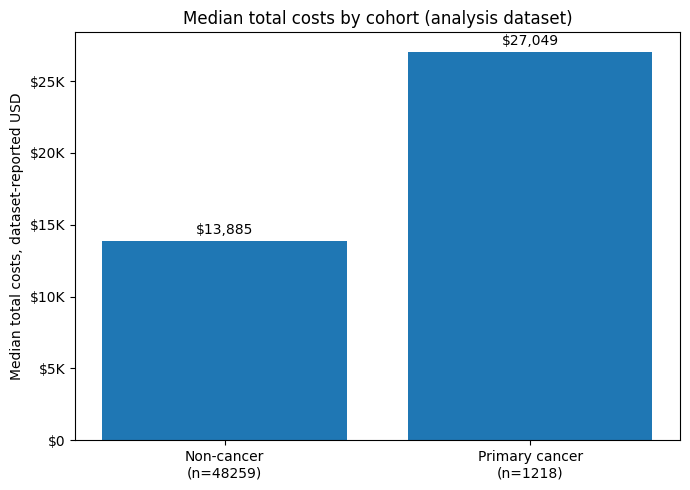

Saved: /Users/marissa/Desktop/portfolio/oncology-health-economics-portfolio/project_01_sparcs_cancer_utilisation_cost/outputs/figures/notebook_03_median_costs_primary_vs_non_cancer.png


In [20]:
# Figure: median total costs by comparison group
# Improvement: currency label, n labels and value labels.

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(plot_table["group_label"], plot_table["median_total_costs"])

ax.set_ylabel("Median total costs, dataset-reported USD")
ax.set_title(f"Median total costs by cohort ({status_label})")
ax.yaxis.set_major_formatter(FuncFormatter(money_formatter))
add_bar_labels(ax, fmt="${:,.0f}", padding=3)

plt.tight_layout()
save_current_figure("notebook_03_median_costs_primary_vs_non_cancer.png")


## 11. Export combined report table

This table gives a compact summary for the project report and README.


In [21]:
report_summary = pd.DataFrame({
    "metric": [
        "Total admissions in cleaned sample",
        "Primary cancer admissions",
        "Broader cancer-related admissions",
        "Primary cancer percentage of all admissions",
        "Median LOS among primary cancer admissions",
        "Median total charges among primary cancer admissions",
        "Median total costs among primary cancer admissions",
        "Most common primary cancer diagnosis group",
        "Dataset status"
    ],
    "value": [
        len(df_clean),
        len(primary_cancer),
        len(broader_cancer),
        round(len(primary_cancer) / len(df_clean) * 100, 2),
        primary_cancer["length_of_stay_clean"].median(),
        primary_cancer["total_charges_clean"].median(),
        primary_cancer["total_costs_clean"].median(),
        primary_diagnosis_mix.iloc[0]["ccsr_diagnosis_description"] if len(primary_diagnosis_mix) > 0 else "Not available",
        dataset_status
    ]
})

report_summary.to_csv(
    outputs_tables / "notebook_03_report_summary.csv",
    index=False
)

display(report_summary)


,metric,value
0,Total admissions in cleaned sample,50000
1,Primary cancer admissions,1218
2,Broader cancer-related admissions,1377
3,Primary cancer percentage of all admissions,2.44
4,Median LOS among primary cancer admissions,4.0
5,Median total charges among primary cancer admi...,91354.615
6,Median total costs among primary cancer admiss...,27048.66
7,Most common primary cancer diagnosis group,RESPIRATORY CANCERS
8,Dataset status,final_analysis_ready


## 12. Final output checklist

After running Notebook 03, expected outputs are:

### Tables

- `outputs/tables/notebook_03_dataset_status_check.csv`
- `outputs/tables/notebook_03_cohort_breakdown.csv`
- `outputs/tables/notebook_03_primary_cancer_diagnosis_mix.csv`
- `outputs/tables/notebook_03_primary_cancer_profile_by_age_group.csv`
- `outputs/tables/notebook_03_primary_cancer_profile_by_gender.csv`
- `outputs/tables/notebook_03_primary_cancer_profile_by_race.csv`
- `outputs/tables/notebook_03_primary_cancer_profile_by_ethnicity.csv`
- `outputs/tables/notebook_03_primary_cancer_profile_by_type_of_admission.csv`
- `outputs/tables/notebook_03_primary_cancer_profile_by_patient_disposition.csv`
- `outputs/tables/notebook_03_primary_cancer_profile_by_primary_payer.csv`
- `outputs/tables/notebook_03_primary_cancer_profile_by_apr_severity_of_illness.csv`
- `outputs/tables/notebook_03_primary_cancer_profile_by_apr_risk_of_mortality.csv`
- `outputs/tables/notebook_03_primary_cancer_profile_by_apr_medical_surgical.csv`
- `outputs/tables/notebook_03_primary_cancer_outcome_summary.csv`
- `outputs/tables/notebook_03_primary_vs_non_cancer_summary.csv`
- `outputs/tables/notebook_03_report_summary.csv`

### Figures

- `outputs/figures/notebook_03_top_primary_cancer_diagnosis_groups.png`
- `outputs/figures/notebook_03_primary_cancer_age_group_distribution.png`
- `outputs/figures/notebook_03_primary_cancer_severity_distribution.png`
- `outputs/figures/notebook_03_primary_cancer_los_distribution.png`
- `outputs/figures/notebook_03_primary_cancer_total_costs_distribution.png`
- `outputs/figures/notebook_03_primary_cancer_log_total_costs_distribution.png`
- `outputs/figures/notebook_03_median_los_primary_vs_non_cancer.png`
- `outputs/figures/notebook_03_median_costs_primary_vs_non_cancer.png`

## Interpretation note

These outputs are descriptive. They describe the cohort and identify early utilisation and cost patterns. They do not yet estimate adjusted associations. Regression modelling should be handled later after the dataset is scaled up beyond the 5,000-row development sample.
